In [ ]:
import pandas as pd
import extract_metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import json
from Bio.PDB import MMCIFParser
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu


In [ ]:
# df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/prediction_records_new.parquet")

# extractor = extract_metrics.NativeMetricExtractor()
# metrics_df = df.apply(
#     extractor.extract_row_metrics,
#     axis=1,
#     result_type="expand"
# )

# df_out = pd.concat([df, metrics_df], axis=1)
# df_out.to_parquet("prediction_records_with_native_metrics.parquet", index=False)

In [ ]:
df = pd.read_parquet("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/Analysis/Data/native_metrics_with_af3_plddt.parquet")

print([c for c in df.columns if c.startswith("af3_")][:30])
print([c for c in df.columns if c.startswith("helixfold3_")][:30])
print([c for c in df.columns if c.startswith("boltz2_")][:30])

['af3_ranking_score', 'af3_ptm', 'af3_iptm', 'af3_fraction_disordered', 'af3_has_clash', 'af3_conf_json_path', 'af3_plddt_mean', 'af3_binder_plddt_mean', 'af3_plddt_status', 'af3_plddt_error']
['helixfold3_ptm', 'helixfold3_iptm', 'helixfold3_has_clash', 'helixfold3_mean_plddt']
['boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 'boltz2_complex_iplddt', 'boltz2_complex_pde', 'boltz2_complex_ipde', 'boltz2_source_json']


In [ ]:
df.columns.to_list()

['path',
 'file_type',
 'method',
 'complex_name',
 'prediction_id',
 'rank',
 'target_chain_id',
 'binder_chain_id',
 'target_length',
 'binder_length',
 'binder_sequence',
 'target_sequence',
 'score',
 'score_name',
 'json_path',
 'pkl_path',
 'npz_path',
 'parse_success',
 'error_message',
 'af2_plddt_mean',
 'af2_plddt_median',
 'af2_plddt_min',
 'af2_plddt_max',
 'af2_ptm',
 'af2_iptm',
 'af3_ranking_score',
 'af3_ptm',
 'af3_iptm',
 'af3_fraction_disordered',
 'af3_has_clash',
 'boltz2_confidence_score',
 'boltz2_ptm',
 'boltz2_iptm',
 'boltz2_ligand_iptm',
 'boltz2_protein_iptm',
 'boltz2_complex_plddt',
 'boltz2_complex_iplddt',
 'boltz2_complex_pde',
 'boltz2_complex_ipde',
 'boltz2_source_json',
 'chai1_aggregate_score',
 'chai1_ptm',
 'chai1_iptm',
 'chai1_has_inter_chain_clashes',
 'helixfold3_ptm',
 'helixfold3_iptm',
 'helixfold3_has_clash',
 'helixfold3_mean_plddt',
 'of3_avg_plddt',
 'of3_gpde',
 'of3_iptm',
 'of3_ptm',
 'of3_disorder',
 'of3_has_clash',
 'of3_sample_r

In [ ]:
complex_name = "violet-shark-wave"

matches = df.loc[
    df["complex_name"] == complex_name,
    ["complex_name", "binder_sequence"]
].drop_duplicates()

matches

,complex_name,binder_sequence
df_index,,
6312,violet-shark-wave,TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF


In [ ]:
binder_seq = matches["binder_sequence"].iloc[0]

print(binder_seq)

TYCLHGTPVYISSLNKWSCVCDKGWYGERCEF


In [ ]:
colsx = [
    "af2_plddt_mean", "af2_iptm",
    "af3_plddt_mean", "af3_iptm",
    "helixfold3_iptm", "helixfold3_mean_plddt",
    "boltz2_iptm", "boltz2_complex_plddt",
    "chai1_iptm",
    "seedfold_complex_plddt", "seedfold_iptm",
    "protenix_plddt", "protenix_iptm",
    "of3_avg_plddt", "of3_iptm"
]

metrics_row = (
    df.loc[df["binder_sequence"] == binder_seq, colsx]
    .drop_duplicates()
)

metrics_row

,af2_plddt_mean,af2_iptm,af3_plddt_mean,af3_iptm,helixfold3_iptm,helixfold3_mean_plddt,boltz2_iptm,boltz2_complex_plddt,chai1_iptm,seedfold_complex_plddt,seedfold_iptm,protenix_plddt,protenix_iptm,of3_avg_plddt,of3_iptm
df_index,,,,,,,,,,,,,,,
1900,91.821763,0.926920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1901,89.606471,0.260797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1902,87.723201,0.254010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1903,87.645342,0.233464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1904,87.814011,0.194845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2275,NaN,NaN,86.628528,0.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2276,NaN,NaN,86.643807,0.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2277,NaN,NaN,86.071807,0.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2278,NaN,NaN,86.430022,0.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
metric_cols = [
    c for c in df.columns
    if c.startswith(("af2_", "af3_", "helixfold3_", "boltz2_", "chai1_", "seedfold_", "protenix_", "of3_"))
]

print("Number of native metric columns:", len(metric_cols))
print(metric_cols)

Number of native metric columns: 68
['af2_plddt_mean', 'af2_plddt_median', 'af2_plddt_min', 'af2_plddt_max', 'af2_ptm', 'af2_iptm', 'af3_ranking_score', 'af3_ptm', 'af3_iptm', 'af3_fraction_disordered', 'af3_has_clash', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 'boltz2_complex_iplddt', 'boltz2_complex_pde', 'boltz2_complex_ipde', 'boltz2_source_json', 'chai1_aggregate_score', 'chai1_ptm', 'chai1_iptm', 'chai1_has_inter_chain_clashes', 'helixfold3_ptm', 'helixfold3_iptm', 'helixfold3_has_clash', 'helixfold3_mean_plddt', 'of3_avg_plddt', 'of3_gpde', 'of3_iptm', 'of3_ptm', 'of3_disorder', 'of3_has_clash', 'of3_sample_ranking_score', 'of3_chain_ptm__A', 'of3_chain_ptm__B', 'of3_chain_pair_iptm__(A, B)', 'of3_bespoke_iptm__(A, B)', 'protenix_plddt', 'protenix_gpde', 'protenix_ptm', 'protenix_iptm', 'protenix_has_clash', 'protenix_disorder', 'protenix_ranking_score', 'protenix_num_recycles', 'seedfold_confiden

In [ ]:
prefixes = ["af2_", "af3_", "helixfold3_", "boltz2_", "chai1_", "seedfold_", "protenix_", "of3_"]

for prefix in prefixes:
    cols = [c for c in df.columns if c.startswith(prefix)]
    print(f"\n{prefix} ({len(cols)} columns)")
    for c in cols:
        print("  ", c)


af2_ (6 columns)
   af2_plddt_mean
   af2_plddt_median
   af2_plddt_min
   af2_plddt_max
   af2_ptm
   af2_iptm

af3_ (10 columns)
   af3_ranking_score
   af3_ptm
   af3_iptm
   af3_fraction_disordered
   af3_has_clash
   af3_conf_json_path
   af3_plddt_mean
   af3_binder_plddt_mean
   af3_plddt_status
   af3_plddt_error

helixfold3_ (4 columns)
   helixfold3_ptm
   helixfold3_iptm
   helixfold3_has_clash
   helixfold3_mean_plddt

boltz2_ (10 columns)
   boltz2_confidence_score
   boltz2_ptm
   boltz2_iptm
   boltz2_ligand_iptm
   boltz2_protein_iptm
   boltz2_complex_plddt
   boltz2_complex_iplddt
   boltz2_complex_pde
   boltz2_complex_ipde
   boltz2_source_json

chai1_ (4 columns)
   chai1_aggregate_score
   chai1_ptm
   chai1_iptm
   chai1_has_inter_chain_clashes

seedfold_ (15 columns)
   seedfold_confidence_score
   seedfold_ptm
   seedfold_iptm
   seedfold_ligand_iptm
   seedfold_protein_iptm
   seedfold_complex_plddt
   seedfold_complex_iplddt
   seedfold_complex_pde
   seedfo

In [ ]:
presence_rows = []

for method in sorted(df["method"].unique()):
    sub = df[df["method"] == method]
    
    row = {"method": method}
    
    for col in metric_cols:
        row[col] = sub[col].notna().sum()
    
    presence_rows.append(row)

presence_df = pd.DataFrame(presence_rows)
presence_df.value_counts()

method      af2_plddt_mean  af2_plddt_median  af2_plddt_min  af2_plddt_max  af2_ptm  af2_iptm  af3_ranking_score  af3_ptm  af3_iptm  af3_fraction_disordered  af3_has_clash  boltz2_confidence_score  boltz2_ptm  boltz2_iptm  boltz2_ligand_iptm  boltz2_protein_iptm  boltz2_complex_plddt  boltz2_complex_iplddt  boltz2_complex_pde  boltz2_complex_ipde  boltz2_source_json  chai1_aggregate_score  chai1_ptm  chai1_iptm  chai1_has_inter_chain_clashes  helixfold3_ptm  helixfold3_iptm  helixfold3_has_clash  helixfold3_mean_plddt  of3_avg_plddt  of3_gpde  of3_iptm  of3_ptm  of3_disorder  of3_has_clash  of3_sample_ranking_score  of3_chain_ptm__A  of3_chain_ptm__B  of3_chain_pair_iptm__(A, B)  of3_bespoke_iptm__(A, B)  protenix_plddt  protenix_gpde  protenix_ptm  protenix_iptm  protenix_has_clash  protenix_disorder  protenix_ranking_score  protenix_num_recycles  seedfold_confidence_score  seedfold_ptm  seedfold_iptm  seedfold_ligand_iptm  seedfold_protein_iptm  seedfold_complex_plddt  seedfold_compl

In [ ]:
presence_binary = presence_df.set_index("method") > 0

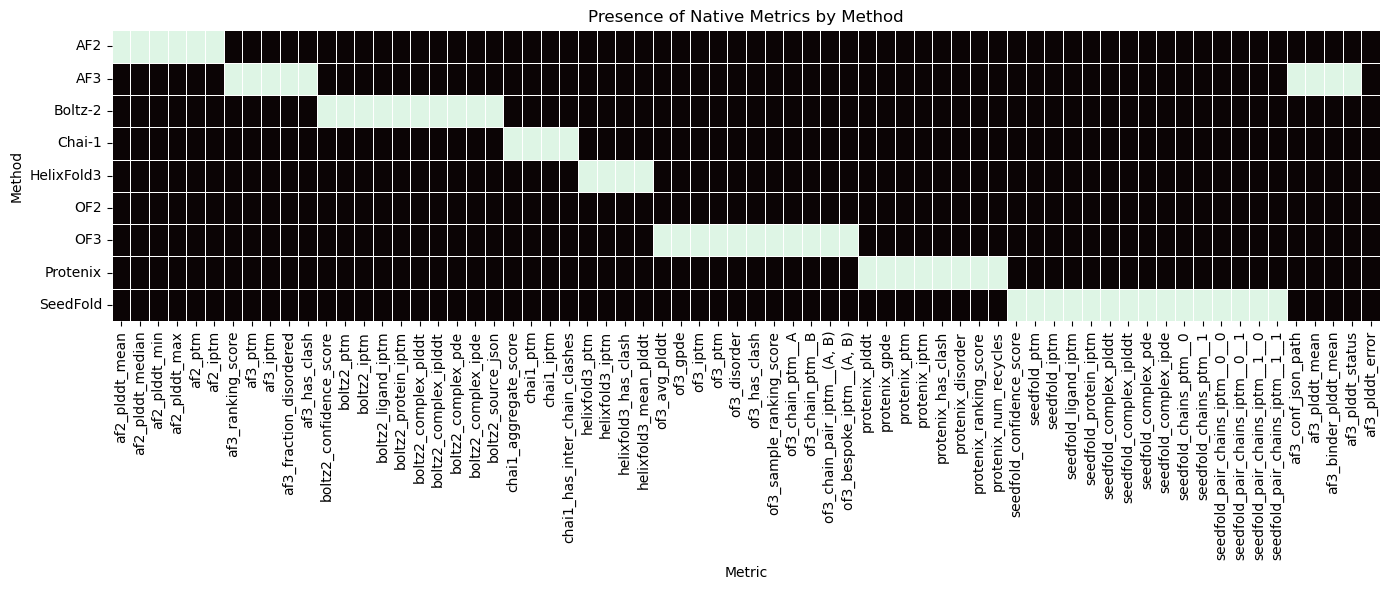

In [ ]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    presence_binary,
    cmap="mako",
    cbar=False,
    linewidths=0.5
)

plt.title("Presence of Native Metrics by Method")
plt.xlabel("Metric")
plt.ylabel("Method")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
df_csv = pd.read_csv("/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AdaptyvBio/contest_2_round_2_metrics_summary.csv")

In [ ]:
df_merged = df.merge(df_csv[["sequence", "design_class", "binding"]], how="left", left_on="binder_sequence", right_on="sequence")
df_merged = df_merged.drop(columns=["sequence"])

In [ ]:
plot_merged = df_merged[df_merged["design_class"].isin(["Miniprotein", "Peptide"])].copy()
print(plot_merged["binding"].value_counts(dropna=False))

binding
False    6290
True      999
Name: count, dtype: int64


In [ ]:
plot_merged["design_class"].unique()


<ArrowStringArray>
['Peptide', 'Miniprotein']
Length: 2, dtype: str

In [ ]:
plot_merged.groupby(["binder_sequence", "method"]).size().value_counts()

5    1379
1     394
Name: count, dtype: int64

In [ ]:
plot_merged.columns.to_list()

['path',
 'file_type',
 'method',
 'complex_name',
 'prediction_id',
 'rank',
 'target_chain_id',
 'binder_chain_id',
 'target_length',
 'binder_length',
 'binder_sequence',
 'target_sequence',
 'score',
 'score_name',
 'json_path',
 'pkl_path',
 'npz_path',
 'parse_success',
 'error_message',
 'af2_plddt_mean',
 'af2_plddt_median',
 'af2_plddt_min',
 'af2_plddt_max',
 'af2_ptm',
 'af2_iptm',
 'af3_ranking_score',
 'af3_ptm',
 'af3_iptm',
 'af3_fraction_disordered',
 'af3_has_clash',
 'boltz2_confidence_score',
 'boltz2_ptm',
 'boltz2_iptm',
 'boltz2_ligand_iptm',
 'boltz2_protein_iptm',
 'boltz2_complex_plddt',
 'boltz2_complex_iplddt',
 'boltz2_complex_pde',
 'boltz2_complex_ipde',
 'boltz2_source_json',
 'chai1_aggregate_score',
 'chai1_ptm',
 'chai1_iptm',
 'chai1_has_inter_chain_clashes',
 'helixfold3_ptm',
 'helixfold3_iptm',
 'helixfold3_has_clash',
 'helixfold3_mean_plddt',
 'of3_avg_plddt',
 'of3_gpde',
 'of3_iptm',
 'of3_ptm',
 'of3_disorder',
 'of3_has_clash',
 'of3_sample_r

In [ ]:
# def af3_confidence_json_from_structure_path(structure_path):
#     """
#     Example:
#     /.../a.tucs.andrejs_tucs_seq1_seed-0_sample-0_model.cif
#     ->
#     /.../a.tucs.andrejs_tucs_seq1_seed-0_sample-0_confidences.json
#     """
#     structure_path = Path(structure_path)
#     stem = structure_path.stem

#     if stem.endswith("_model"):
#         conf_name = stem[:-6] + "_confidences.json"   # remove "_model"
#     else:
#         conf_name = stem + "_confidences.json"

#     conf_path = structure_path.with_name(conf_name)
#     return conf_path


# def parse_structure_atoms_in_order(cif_path):
#     parser = MMCIFParser(QUIET=True)
#     structure = parser.get_structure("af3_model", str(cif_path))
#     return list(structure.get_atoms())


# def extract_af3_plddt_metrics(structure_path, binder_chain_id):
#     structure_path = Path(structure_path)

#     result = {
#         "af3_conf_json_path": None,
#         "af3_plddt_mean": np.nan,
#         "af3_binder_plddt_mean": np.nan,
#         "af3_plddt_status": "ok",
#         "af3_plddt_error": None,
#     }

#     try:
#         if not structure_path.exists():
#             raise FileNotFoundError(f"Structure file not found: {structure_path}")

#         conf_path = af3_confidence_json_from_structure_path(structure_path)
#         result["af3_conf_json_path"] = str(conf_path)

#         if not conf_path.exists():
#             raise FileNotFoundError(f"Confidence JSON not found: {conf_path}")

#         with open(conf_path, "r") as f:
#             conf_data = json.load(f)

#         atom_plddts = conf_data.get("atom_plddts", None)
#         if atom_plddts is None:
#             raise KeyError(f"'atom_plddts' not found in {conf_path}")

#         atom_plddts = np.asarray(atom_plddts, dtype=float)
#         if atom_plddts.size == 0:
#             raise ValueError(f"'atom_plddts' is empty in {conf_path}")

#         atoms = parse_structure_atoms_in_order(structure_path)

#         if len(atoms) != len(atom_plddts):
#             raise ValueError(
#                 f"Atom count mismatch for {structure_path.name}: "
#                 f"{len(atoms)} atoms in structure vs {len(atom_plddts)} pLDDT values"
#             )

#         result["af3_plddt_mean"] = float(np.mean(atom_plddts))

#         binder_vals = []
#         for atom, plddt in zip(atoms, atom_plddts):
#             chain_id = atom.get_parent().get_parent().id  # atom -> residue -> chain
#             if str(chain_id) == str(binder_chain_id):
#                 binder_vals.append(plddt)

#         if len(binder_vals) == 0:
#             raise ValueError(
#                 f"No atoms found for binder_chain_id={binder_chain_id} in {structure_path}"
#             )

#         result["af3_binder_plddt_mean"] = float(np.mean(binder_vals))

#     except Exception as e:
#         result["af3_plddt_status"] = "error"
#         result["af3_plddt_error"] = str(e)

#     return result


# def add_af3_plddt_columns(df_in):
#     df = df_in.copy()

#     af3_df = df[df["method"] == "AF3"].copy()

#     required_cols = ["path", "binder_chain_id"]
#     missing = [c for c in required_cols if c not in af3_df.columns]
#     if missing:
#         raise KeyError(f"Missing required columns in AF3 rows: {missing}")

#     records = []

#     for idx, row in tqdm(af3_df.iterrows(), total=len(af3_df), desc="Extracting AF3 pLDDT"):
#         metrics = extract_af3_plddt_metrics(
#             structure_path=row["path"],
#             binder_chain_id=row["binder_chain_id"],
#         )

#         rec = {"df_index": idx}
#         rec.update(metrics)
#         records.append(rec)

#     af3_metrics_df = pd.DataFrame(records)

#     df = df.reset_index().rename(columns={"index": "df_index"})
#     df = df.merge(
#         af3_metrics_df,
#         on="df_index",
#         how="left",
#     )
#     df = df.set_index("df_index").sort_index()

#     return df, af3_metrics_df

# plot_merged_updated, af3_plddt_df = add_af3_plddt_columns(df)

In [ ]:
plot_merged_top1 = plot_merged[plot_merged["rank"] == 1].copy()

In [ ]:
plddt_methods = [
    "AF2", "AF3", "HelixFold3",
    "Boltz-2", "SeedFold",
    "Protenix", "OF3"
]

metric_map = {
    "AF2": "af2_plddt_median",
    "AF3": "af3_plddt_mean",
    "HelixFold3": "helixfold3_mean_plddt",
    "Boltz-2": "boltz2_complex_plddt",
#    "Chai-1": "chai1_iptm",   # fine for other analyses, but not pLDDT plot
    "SeedFold": "seedfold_complex_plddt",
    "Protenix": "protenix_plddt",
    "OF3": "of3_avg_plddt",
}

# Create primary_score first
plot_merged_top1["primary_score"] = plot_merged_top1.apply(
    lambda row: row[metric_map[row["method"]]]
    if row["method"] in metric_map and pd.notna(row.get(metric_map[row["method"]], None))
    else None,
    axis=1
)
# Fix scaling
plot_merged_top1.loc[plot_merged_top1["method"] == "SeedFold", "primary_score"] *= 100
plot_merged_top1.loc[plot_merged_top1["method"] == "Boltz-2", "primary_score"] *= 100

df_plddt = plot_merged_top1[
    plot_merged_top1["method"].isin(plddt_methods)
].copy()

df_plddt = df_plddt.dropna(subset=["primary_score"])

In [ ]:
df_plddt.columns.to_list()

['path',
 'file_type',
 'method',
 'complex_name',
 'prediction_id',
 'rank',
 'target_chain_id',
 'binder_chain_id',
 'target_length',
 'binder_length',
 'binder_sequence',
 'target_sequence',
 'score',
 'score_name',
 'json_path',
 'pkl_path',
 'npz_path',
 'parse_success',
 'error_message',
 'af2_plddt_mean',
 'af2_plddt_median',
 'af2_plddt_min',
 'af2_plddt_max',
 'af2_ptm',
 'af2_iptm',
 'af3_ranking_score',
 'af3_ptm',
 'af3_iptm',
 'af3_fraction_disordered',
 'af3_has_clash',
 'boltz2_confidence_score',
 'boltz2_ptm',
 'boltz2_iptm',
 'boltz2_ligand_iptm',
 'boltz2_protein_iptm',
 'boltz2_complex_plddt',
 'boltz2_complex_iplddt',
 'boltz2_complex_pde',
 'boltz2_complex_ipde',
 'boltz2_source_json',
 'chai1_aggregate_score',
 'chai1_ptm',
 'chai1_iptm',
 'chai1_has_inter_chain_clashes',
 'helixfold3_ptm',
 'helixfold3_iptm',
 'helixfold3_has_clash',
 'helixfold3_mean_plddt',
 'of3_avg_plddt',
 'of3_gpde',
 'of3_iptm',
 'of3_ptm',
 'of3_disorder',
 'of3_has_clash',
 'of3_sample_r

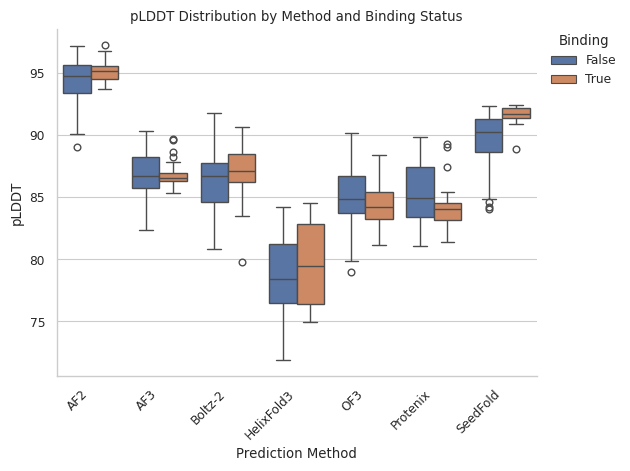

In [ ]:
df_plot = plot_merged_top1[plot_merged_top1["method"] != "OF2"].copy()

sns.set_theme(
    style="whitegrid",
    context="paper",   # IMPORTANT: scales fonts for publication
)

ax = sns.boxplot(
    data=df_plddt,
    x="method",
    y="primary_score",
    hue="binding"
)

sns.despine()

ax.set_xlabel("Prediction Method")
ax.set_ylabel("pLDDT")
ax.set_title("pLDDT Distribution by Method and Binding Status")

# Move legend outside
ax.legend(
    title="Binding",
    bbox_to_anchor=(1.02, 1),   # outside right
    loc="upper left",
    borderaxespad=0,
    frameon=False
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
print(plot_merged["binding"].dtype)

print(plot_merged["binding"].value_counts(dropna=False))

print(
    plot_merged.groupby("method")["binding"]
    .value_counts(dropna=False)
)

object
binding
False    6290
True      999
Name: count, dtype: int64
method      binding
AF2         False      850
            True       135
AF3         False      850
            True       135
Boltz-2     False      170
            True        27
Chai-1      False      850
            True       135
HelixFold3  False      850
            True       135
OF2         False      170
            True        27
OF3         False      850
            True       135
Protenix    False      850
            True       135
SeedFold    False      850
            True       135
Name: count, dtype: int64
